# Сводка результатов файнтюна

Проходит по всем `results/finetune/*.json`, складывает в один CSV (`results/all_methods_comparison.csv`) и рисует top-N бары по метрикам.

In [4]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results' / 'finetune'
OUT_CSV = PROJECT_ROOT / 'results' / 'all_methods_comparison.csv'

TOP_N = 10
ROUND = 4

print(f'Сканирую: {RESULTS_DIR}')

Сканирую: /Users/kvt/Documents/VKR/code/results/finetune


In [7]:
rows = []
for path in sorted(RESULTS_DIR.glob('*.json')):
    with open(path, 'r', encoding='utf-8') as f:
        r = json.load(f)
    rows.append({
        'run_key': r.get('run_key', path.stem),
        'method': r.get('method'),
        'model': r.get('model'),
        'balanced_accuracy': r.get('balanced_accuracy'),
        'macro_f1': r.get('macro_f1'),
        'f1_group_A': r.get('f1_group_A'),
        'f1_group_B': r.get('f1_group_B'),
        'f1_group_C': r.get('f1_group_C'),
        'trainable_params': r.get('trainable_params'),
        'train_time_sec': r.get('train_time_sec'),
        'timestamp': r.get('timestamp'),
    })

df = pd.DataFrame(rows)

# Округляем все числовые метрики до ROUND знаков
metric_cols = ['balanced_accuracy', 'macro_f1', 'f1_group_A', 'f1_group_B', 'f1_group_C']
for c in metric_cols:
    df[c] = df[c].astype(float).round(ROUND)

df = df.sort_values('macro_f1', ascending=False).reset_index(drop=True)

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)
print(f'Сохранено: {OUT_CSV} ({len(df)} прогонов)')
df

Сохранено: /Users/kvt/Documents/VKR/code/results/all_methods_comparison.csv (9 прогонов)


,run_key,method,model,balanced_accuracy,macro_f1,f1_group_A,f1_group_B,f1_group_C,trainable_params,train_time_sec,timestamp
0,qwen3_32b_qlora_cw,qlora,Qwen/Qwen3-32B,0.5601,0.5323,0.7497,0.5182,0.5889,134402048,22252.401453,2026-05-08T02:55:33
1,qlora_t_pro_it_2_1,qlora,t-tech/T-pro-it-2.1,0.5299,0.5295,0.7306,0.4661,0.5972,268619776,11124.309681,2026-04-24T02:22:44
2,lora_qwen3_14b,lora,Qwen/Qwen3-14B,0.5378,0.5186,0.7256,0.5405,0.5056,64409600,5265.905767,2026-04-24T00:43:18
3,qwen3_32b_qlora_no_cw_r32,qlora,Qwen/Qwen3-32B,0.5097,0.4970,0.7705,0.5086,0.4222,268619776,25274.308666,2026-05-08T03:46:29
4,qwen3_32b_qlora_cw_r32,qlora,Qwen/Qwen3-32B,0.5138,0.4925,0.7830,0.5343,0.4500,268619776,25481.150071,2026-05-08T03:49:44
5,adalora_qwen3_32b,adalora,Qwen/Qwen3-32B,0.4940,0.4783,0.7404,0.5114,0.4500,100852992,24483.783265,2026-04-22T00:20:22
6,qwen3_32b_qlora_no_cw,qlora,Qwen/Qwen3-32B,0.5149,0.4774,0.7221,0.4735,0.5333,134402048,22091.693160,2026-05-08T02:53:13
7,lora_vikhr_nemo_12b_instruct_r_21_09_24,lora,Vikhrmodels/Vikhr-Nemo-12B-Instruct-R-21-09-24,0.5078,0.4733,0.7253,0.4959,0.4583,57200640,3991.039614,2026-04-24T00:21:29
8,adalora_t_pro_it_2_1,adalora,t-tech/T-pro-it-2.1,0.4489,0.4167,0.6408,0.5255,0.3472,134409216,12266.637959,2026-04-24T02:41:04


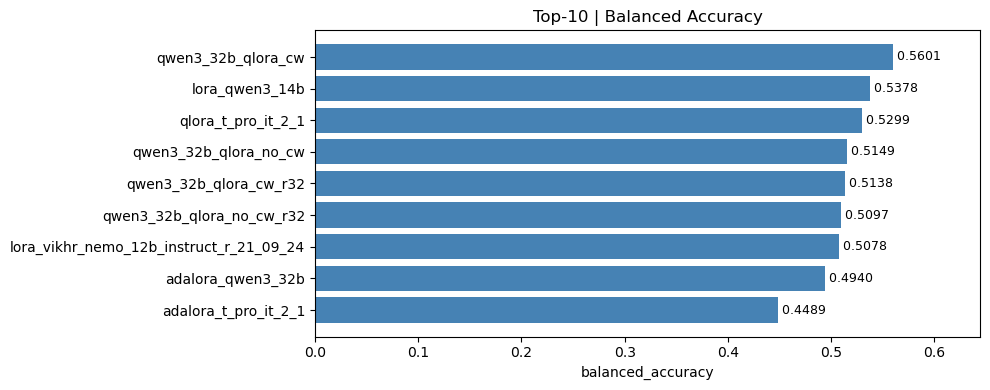

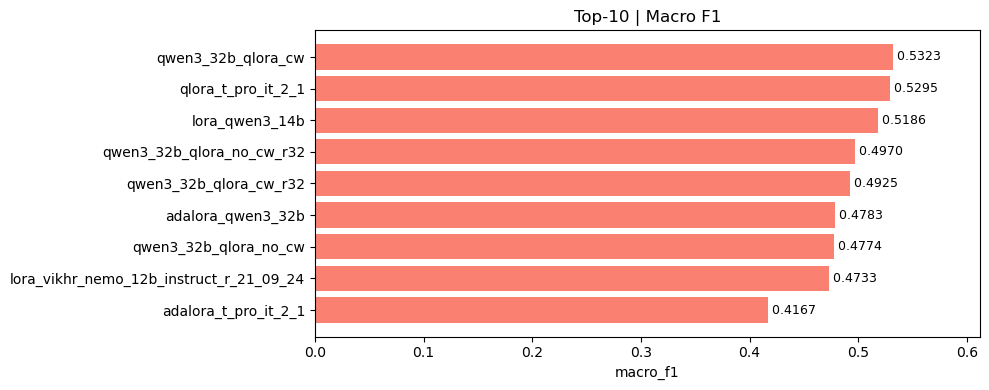

In [8]:
def plot_top(df, metric, title, color):
    top = df.sort_values(metric, ascending=False).head(TOP_N).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(top))))
    ax.barh(top['run_key'], top[metric], color=color)
    ax.set_xlabel(metric)
    ax.set_title(f'Top-{TOP_N} | {title}')
    for i, v in enumerate(top[metric]):
        ax.text(v, i, f' {v:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, max(top[metric].max() * 1.15, 0.05))
    plt.tight_layout()
    plt.show()

if not df.empty:
    plot_top(df, 'balanced_accuracy', 'Balanced Accuracy', 'steelblue')
    plot_top(df, 'macro_f1',          'Macro F1',          'salmon')
else:
    print('Нет результатов для построения графиков.')